In [1]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from itertools import product
import warnings

warnings.filterwarnings("ignore")

from zadu.measures import class_aware_trustworthiness_continuity


/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dist_mat = np.load('dist_mat.npy')
labels = np.load('ship-types.npy')
original_data = np.load('original_data.npy')

print("Original data shape:", original_data.shape)

global_all_results = []



Original data shape: (750, 25, 10)


# MDS

In [3]:
def plot_mds(
    data,
    original_data,
    labels,
    ax=None,
    random_state=42,
    n_init=4,
    max_iter=300,
    eps=1e-6,
    normalized_stress="auto",
    title="MDS"
):
    # FIXED: dissimilarity="precomputed", metric=True, removed init
    embedding = MDS(
        n_components=2,
        dissimilarity="precomputed",  
        metric=True,                  
        random_state=random_state,
        n_init=n_init,                
        max_iter=max_iter,
        eps=eps,
        normalized_stress=normalized_stress
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=25,
        alpha=0.8,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))
    knn_score = float(np.mean(knn_scores))
    best_k = int(np.argmax(knn_scores) + 5)

    print(
        f"{title} | "
        f"CA Cont {cont_score:.4f} | "
        f"CA Trust {trust_score:.4f} | "
        f"KNN {knn_score:.3f} | "
        f"Geriausias k KNN {best_k}"
    )

    return embedding, {
        "ca_continuity": cont_score,
        "ca_trustworthiness": trust_score,
        "knn_accuracy": knn_score,
        "best_k": best_k
    }



In [4]:
def plot_mds_param(
    param_name,
    param_values,
    distance_matrix,
    original_data,
    labels,
    random_state=42
):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    default_params = {
        "n_init": 4,
        "max_iter": 300,
        "eps": 1e-6
    }

    results = []

    for i, val in enumerate(param_values):
        params = default_params.copy()
        params[param_name] = val

        _, scores = plot_mds(
            data=distance_matrix,
            original_data=original_data,
            labels=labels,
            ax=axes[i],
            random_state=random_state,
            title=f"{param_name} = {val}",
            **params
        )

        # ADDED: Append to local and global results
        res_dict = {param_name: val, **scores}
        results.append(res_dict)
        global_all_results.append({"Method": "MDS", **res_dict})

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)


## paleidimas

In [5]:

default_mds_hyperparams = {
    "n_init": [1, 4, 8, 32],
    "max_iter": [25, 50, 200, 400],
    "eps": [1e-3, 1e-4, 1e-5, 1e-6],
}


n_init = 1 | CA Cont 0.9827 | CA Trust 0.9530 | KNN 0.590 | Geriausias k KNN 5
n_init = 4 | CA Cont 0.9836 | CA Trust 0.9508 | KNN 0.599 | Geriausias k KNN 5
n_init = 8 | CA Cont 0.9836 | CA Trust 0.9508 | KNN 0.599 | Geriausias k KNN 5
n_init = 32 | CA Cont 0.9868 | CA Trust 0.9474 | KNN 0.588 | Geriausias k KNN 8


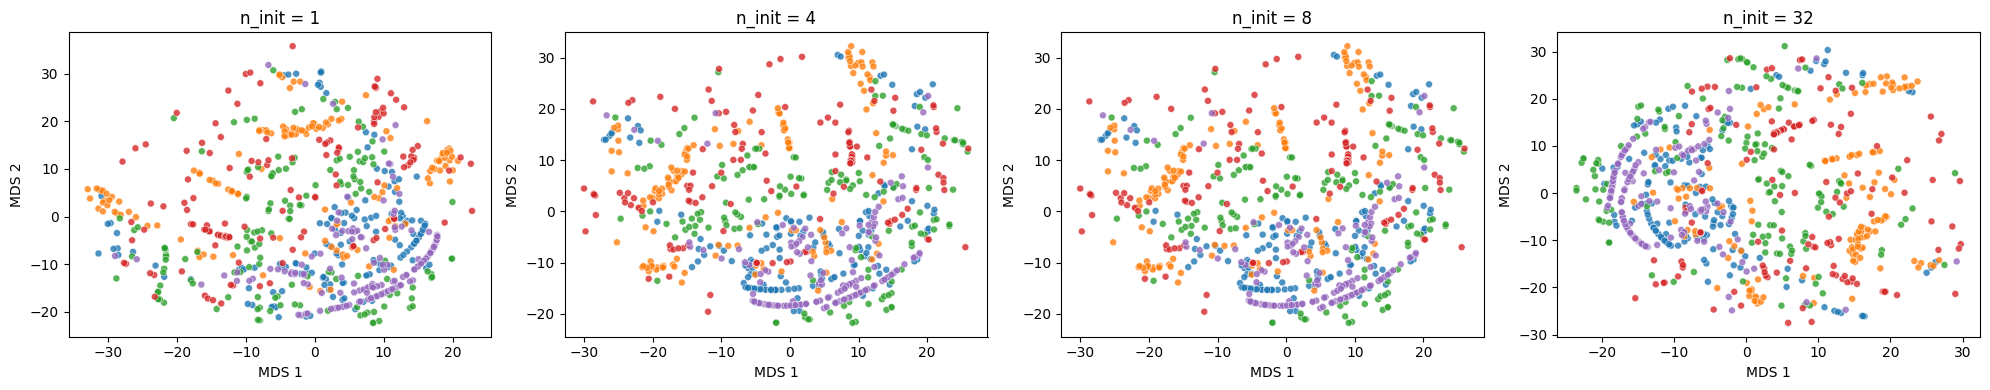

In [6]:
mds_n_init_results = plot_mds_param("n_init", default_mds_hyperparams["n_init"], dist_mat, original_data, labels)

max_iter = 25 | CA Cont 0.8443 | CA Trust 0.8188 | KNN 0.450 | Geriausias k KNN 11
max_iter = 50 | CA Cont 0.9295 | CA Trust 0.8964 | KNN 0.514 | Geriausias k KNN 7
max_iter = 200 | CA Cont 0.9836 | CA Trust 0.9508 | KNN 0.599 | Geriausias k KNN 5
max_iter = 400 | CA Cont 0.9836 | CA Trust 0.9508 | KNN 0.599 | Geriausias k KNN 5


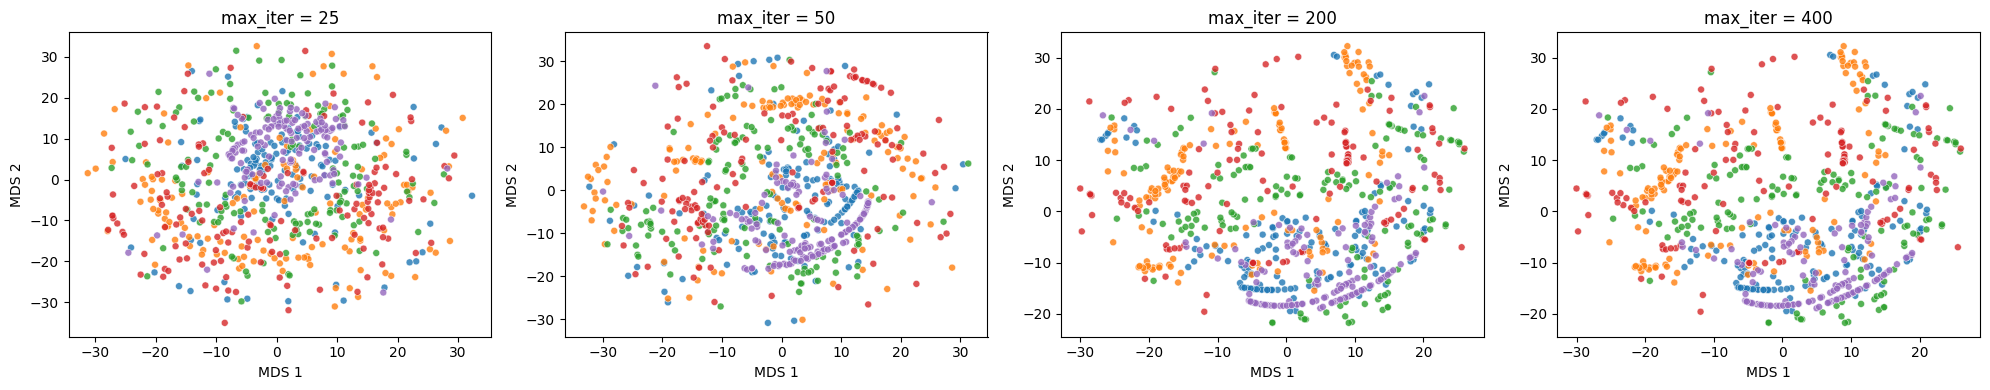

In [7]:
mds_max_iter_results = plot_mds_param("max_iter", default_mds_hyperparams["max_iter"], dist_mat, original_data, labels)

eps = 0.001 | CA Cont 0.9614 | CA Trust 0.9170 | KNN 0.563 | Geriausias k KNN 9
eps = 0.0001 | CA Cont 0.9795 | CA Trust 0.9374 | KNN 0.576 | Geriausias k KNN 5
eps = 1e-05 | CA Cont 0.9823 | CA Trust 0.9446 | KNN 0.583 | Geriausias k KNN 6
eps = 1e-06 | CA Cont 0.9836 | CA Trust 0.9508 | KNN 0.599 | Geriausias k KNN 5


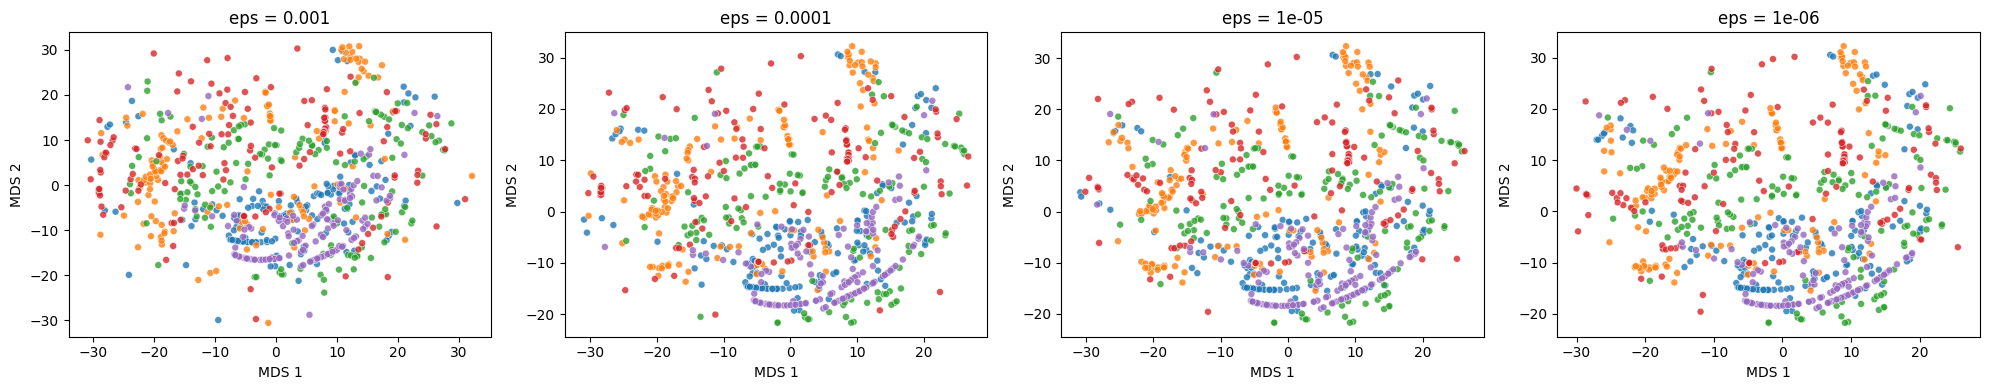

In [8]:
mds_eps_results = plot_mds_param("eps", default_mds_hyperparams["eps"], dist_mat, original_data, labels)

# T-SNE

In [9]:

## =========================================================
## t-SNE tyrimas
## =========================================================
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels)


In [10]:

def plot_tsne_param(param_name, param_values, distance_matrix, labels=None, random_state=42):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, val in enumerate(param_values):
        params = {param_name: val}

        max_iter = 1000 if param_name != 'max_iter' else val
        perplexity = 50 if param_name != 'perplexity' else val

        if param_name in ['max_iter', 'perplexity']:
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                max_iter=max_iter, perplexity=perplexity, init="random",
            )
        elif param_name == 'max_iter':
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                perplexity=perplexity, init="random", **params
            )
        elif param_name == 'perplexity':
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                max_iter=max_iter, init="random", **params
            )
        else:
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                init="random", **params
            )

        embedding = tsne.fit_transform(distance_matrix)
        ax = axes[i]
        original_flat = original_data.reshape(len(original_data), -1)
        
        trust_scores = []
        cont_scores = []
        knn_scores = []

        for k in range(5, 30):
            ca_tc = class_aware_trustworthiness_continuity.measure(
                original_flat, embedding, label=labels, k=k
            )
            trust_scores.append(ca_tc["ca_trustworthiness"]) # Note: your original didn't divide by 25 here
            cont_scores.append(ca_tc["ca_continuity"])
            knn = KNeighborsClassifier(n_neighbors=k)
            knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

        trust_score = np.mean(trust_scores)
        cont_score = np.mean(cont_scores)
        knn_score = np.mean(knn_scores)
        best_k = np.argmax(knn_scores) + 5

        print(
            "Value:", val, "CA Continuity", cont_score, "CA Trustworthiness", trust_score,
            "KNN", knn_score, "Geriausias k KNN", best_k
        )

        if labels is not None:
            sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette="tab10", ax=ax, legend=False)
        else:
            ax.scatter(embedding[:, 0], embedding[:, 1])

        ax.set_title(f"{param_name} = {val}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## paleidimas

In [11]:

default_tsne_hyperparams = {
    "perplexity":         [5, 50, 200],
    "max_iter":             [250, 500, 2000],
    "early_exaggeration": [4.0, 12.0, 24.0],
    "learning_rate":      [10, 100, 1000],
}

keys = list(default_tsne_hyperparams.keys())
values = list(default_tsne_hyperparams.values())
tsne_results = []

for combo in product(*values):
    params = dict(zip(keys, combo))

    embedding = TSNE(
        perplexity         = params["perplexity"],
        max_iter           = params["max_iter"],
        early_exaggeration = params["early_exaggeration"],
        learning_rate      = params["learning_rate"],
        metric             = "precomputed",
        init               = "random",
        random_state       = 42,
    ).fit_transform(dist_mat)

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat, embedding, label=labels, k=k
        )
        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    res_dict = {
        **params,
        "ca_trustworthiness": trust_score, 
        "ca_continuity": cont_score,
        "knn_accuracy": knn_score,
        "best_k": best_k
    }
    tsne_results.append(res_dict)
    global_all_results.append({"Method": "t-SNE", **res_dict})


Value: 5 CA Continuity 0.9814010168954995 CA Trustworthiness 0.9798998740209375 KNN 0.6604800000000001 Geriausias k KNN 5
Value: 50 CA Continuity 0.9934172587755878 CA Trustworthiness 0.9909562919585944 KNN 0.6227733333333333 Geriausias k KNN 5
Value: 200 CA Continuity 0.9934689691988237 CA Trustworthiness 0.9865498737301326 KNN 0.6025066666666666 Geriausias k KNN 5


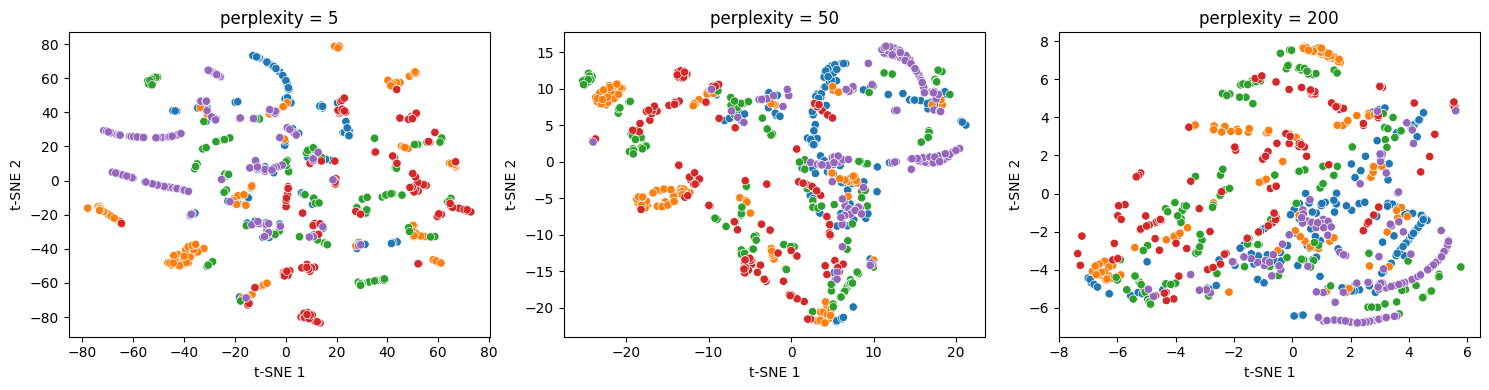

In [12]:

plot_tsne_param("perplexity", default_tsne_hyperparams['perplexity'], dist_mat, labels=labels)

Value: 250 CA Continuity 0.9902317769807708 CA Trustworthiness 0.9510355972639293 KNN 0.5996266666666666 Geriausias k KNN 6
Value: 500 CA Continuity 0.9935165031368385 CA Trustworthiness 0.9896567504763147 KNN 0.6206933333333333 Geriausias k KNN 5
Value: 2000 CA Continuity 0.9933506009951496 CA Trustworthiness 0.9911170973143 KNN 0.62224 Geriausias k KNN 5


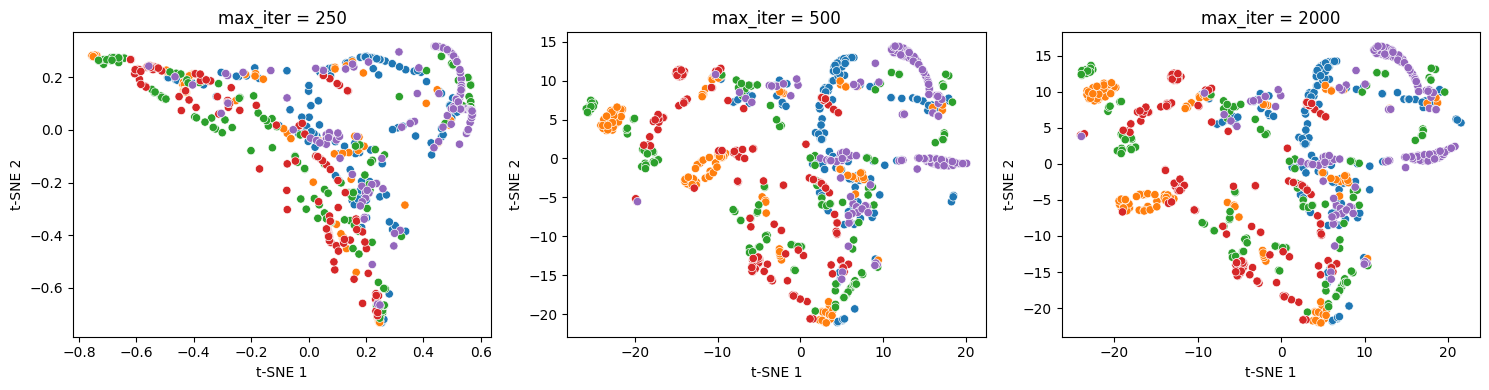

In [13]:
plot_tsne_param("max_iter", default_tsne_hyperparams['max_iter'], dist_mat, labels=labels)

Value: 4.0 CA Continuity 0.9912616267427786 CA Trustworthiness 0.9914810274883264 KNN 0.6343466666666667 Geriausias k KNN 5
Value: 12.0 CA Continuity 0.9932304869478672 CA Trustworthiness 0.9912697926948709 KNN 0.62576 Geriausias k KNN 5
Value: 24.0 CA Continuity 0.9926628206595187 CA Trustworthiness 0.9922591374144347 KNN 0.6232533333333334 Geriausias k KNN 5


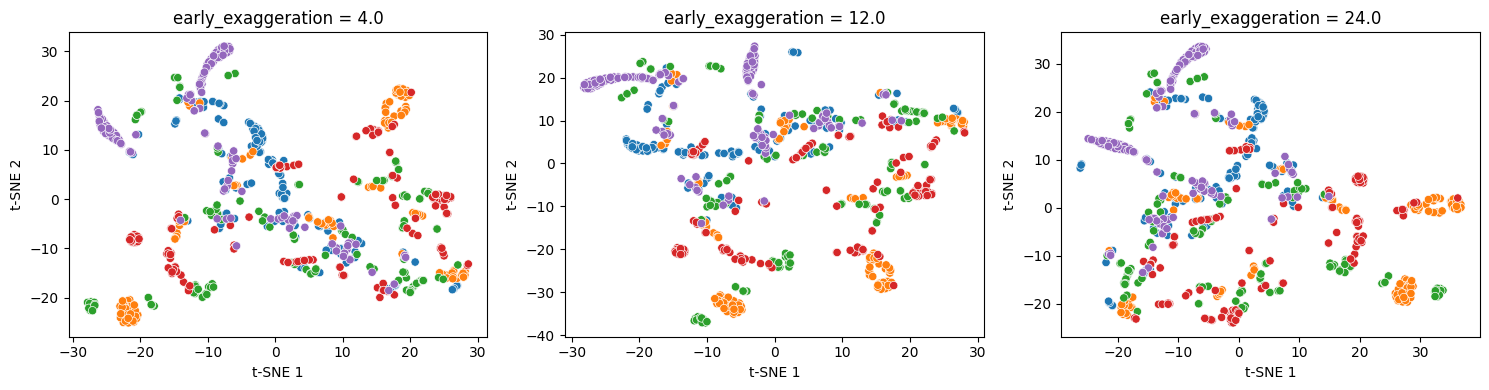

In [14]:
plot_tsne_param("early_exaggeration", default_tsne_hyperparams['early_exaggeration'], dist_mat, labels=labels)

Value: 10 CA Continuity 0.9931891616870068 CA Trustworthiness 0.9921046713580404 KNN 0.6335466666666667 Geriausias k KNN 5
Value: 100 CA Continuity 0.9932639129774009 CA Trustworthiness 0.9920718909419028 KNN 0.6351466666666666 Geriausias k KNN 5
Value: 1000 CA Continuity 0.9926562972065145 CA Trustworthiness 0.9903141649390961 KNN 0.62976 Geriausias k KNN 5


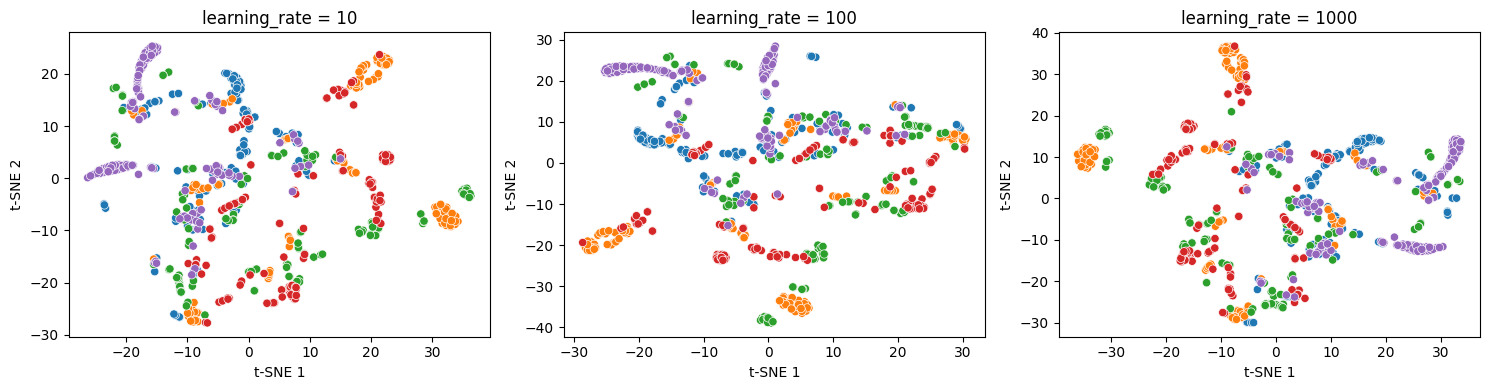

In [15]:
plot_tsne_param("learning_rate", default_tsne_hyperparams['learning_rate'], dist_mat, labels=labels)

# UMAP

In [16]:
def search_umap_params(
    distance_matrix, labels, n_neighbors_list, min_dist_list, n_epochs_list, learning_rate_list, random_state=42
):
    results = []
    original_flat = original_data.reshape(len(original_data), -1)

    for nn in n_neighbors_list:
        for md in min_dist_list:
            for ne in n_epochs_list:
                for lr in learning_rate_list:
                    print(f"Testing: neighbors={nn}, min_dist={md}, epochs={ne}, lr={lr}")

                    umap_model = UMAP(
                        n_neighbors=nn, min_dist=md, n_epochs=ne, learning_rate=lr,
                        metric="precomputed", random_state=random_state
                    )

                    embedding = umap_model.fit_transform(distance_matrix)

                    trust_scores = []
                    cont_scores = []
                    knn_scores = []

                    for k in range(5, 30):
                        ca_tc = class_aware_trustworthiness_continuity.measure(
                            original_flat, embedding, label=labels, k=k
                        )
                        trust_scores.append( ca_tc["ca_trustworthiness"])
                        cont_scores.append( ca_tc["ca_continuity"] )

                        knn = KNeighborsClassifier(n_neighbors=k)
                        knn_scores.append( cross_val_score(knn, embedding, labels, cv=5).mean() )

                    res_dict = {
                        "n_neighbors": nn, "min_dist": md, "n_epochs": ne, "learning_rate": lr,
                        "ca_trustworthiness": np.mean(trust_scores), "ca_continuity": np.mean(cont_scores), "knn_accuracy": np.mean(knn_scores)
                    }
                    results.append(res_dict)
                    
                    # ADDED: Append to global array
                    global_all_results.append({"Method": "UMAP", **res_dict})

    df = pd.DataFrame(results)
    df["score"] = df["knn_accuracy"] + df["ca_trustworthiness"] + df["ca_continuity"]
    best = df.sort_values("score", ascending=False).iloc[0]

    return df, best


In [17]:

## =========================================================
## UMAP tyrimas
## =========================================================
def plot_umap(
    data, min_dist=0.01, n_neighbors=20, n_epochs=None, learning_rate=1.0, ax=None, var="min_dist"
):
    embedding = UMAP(
        n_neighbors=n_neighbors, min_dist=min_dist, n_epochs=n_epochs,
        learning_rate=learning_rate, metric="precomputed", random_state=1
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette="tab10", s=25, alpha=0.8, legend=False, ax=ax)
    ax.set_title(f"{var}={locals()[var]}")

    original_flat = original_data.reshape(len(original_data), -1)
    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat, embedding, label=labels, k=k
        )
        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])
        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    print(f"{var}={locals()[var]} | CA Cont {cont_score:.4f} | CA Trust {trust_score:.4f} | KNN {knn_score:.3f} | Geriausias k KNN {best_k} |")


## paleidimas

min_dist=0.1 | CA Cont 0.9874 | CA Trust 0.9884 | KNN 0.609 | Geriausias k KNN 6 |
min_dist=0.001 | CA Cont 0.9868 | CA Trust 0.9883 | KNN 0.608 | Geriausias k KNN 6 |
min_dist=0.0001 | CA Cont 0.9877 | CA Trust 0.9879 | KNN 0.604 | Geriausias k KNN 5 |
min_dist=1e-05 | CA Cont 0.9874 | CA Trust 0.9881 | KNN 0.606 | Geriausias k KNN 7 |


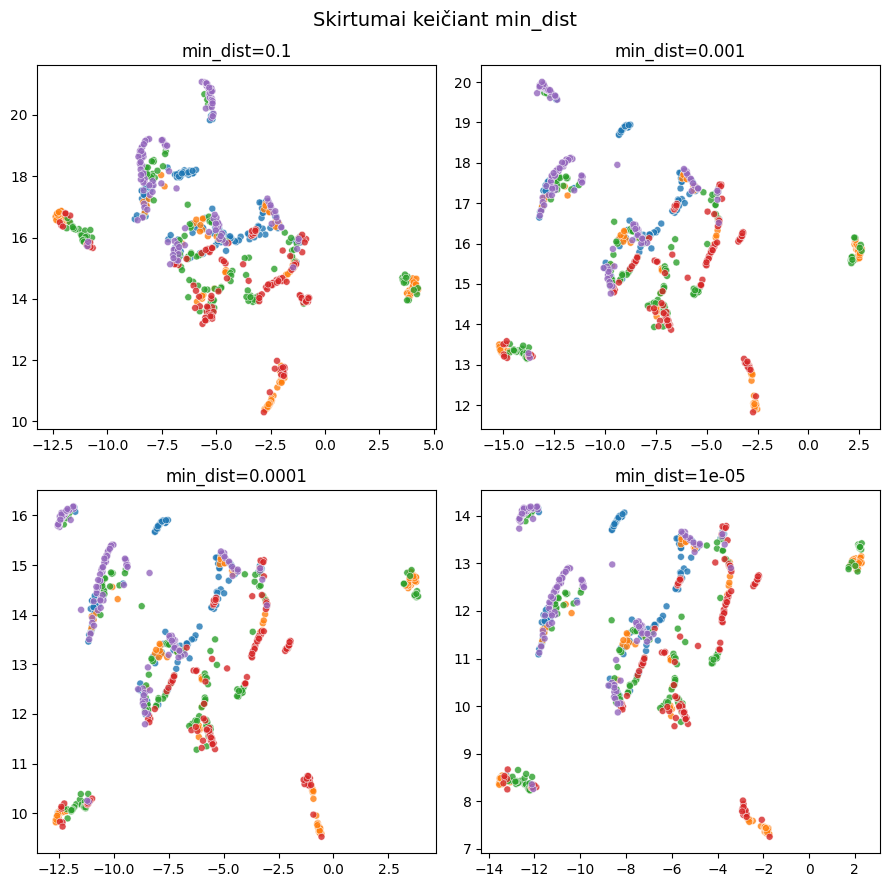

In [18]:

min_distances = [0.1, 0.001, 0.0001, 0.00001]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant min_dist', fontsize=14)
for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i], var='min_dist')
plt.tight_layout()
plt.show()


n_neighbors=5 | CA Cont 0.9566 | CA Trust 0.9606 | KNN 0.632 | Geriausias k KNN 5 |
n_neighbors=10 | CA Cont 0.9801 | CA Trust 0.9843 | KNN 0.646 | Geriausias k KNN 5 |
n_neighbors=20 | CA Cont 0.9870 | CA Trust 0.9884 | KNN 0.610 | Geriausias k KNN 8 |
n_neighbors=50 | CA Cont 0.9851 | CA Trust 0.9762 | KNN 0.572 | Geriausias k KNN 9 |


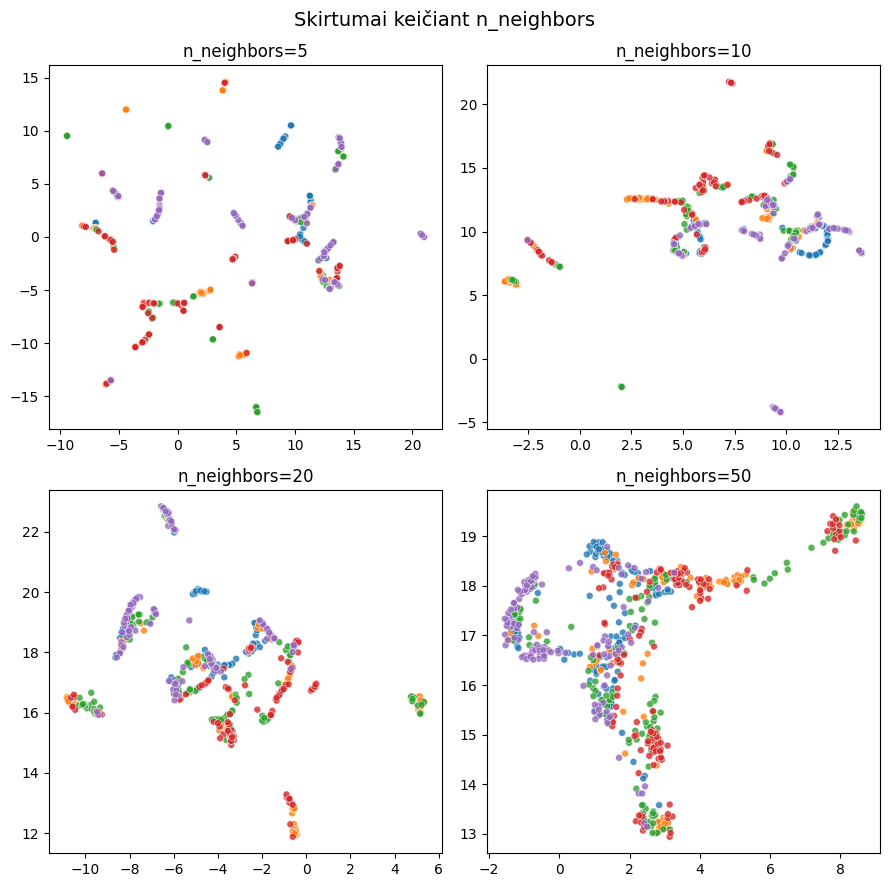

In [19]:

neighbors = [5, 10, 20, 50]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)
for i, n in enumerate(neighbors):
    plot_umap(data=dist_mat, n_neighbors=n, ax=axs[i], var='n_neighbors')
plt.tight_layout()
plt.show()


n_epochs=25 | CA Cont 0.9883 | CA Trust 0.9834 | KNN 0.601 | Geriausias k KNN 7 |
n_epochs=50 | CA Cont 0.9893 | CA Trust 0.9854 | KNN 0.616 | Geriausias k KNN 5 |
n_epochs=100 | CA Cont 0.9881 | CA Trust 0.9866 | KNN 0.596 | Geriausias k KNN 5 |
n_epochs=300 | CA Cont 0.9894 | CA Trust 0.9878 | KNN 0.611 | Geriausias k KNN 8 |


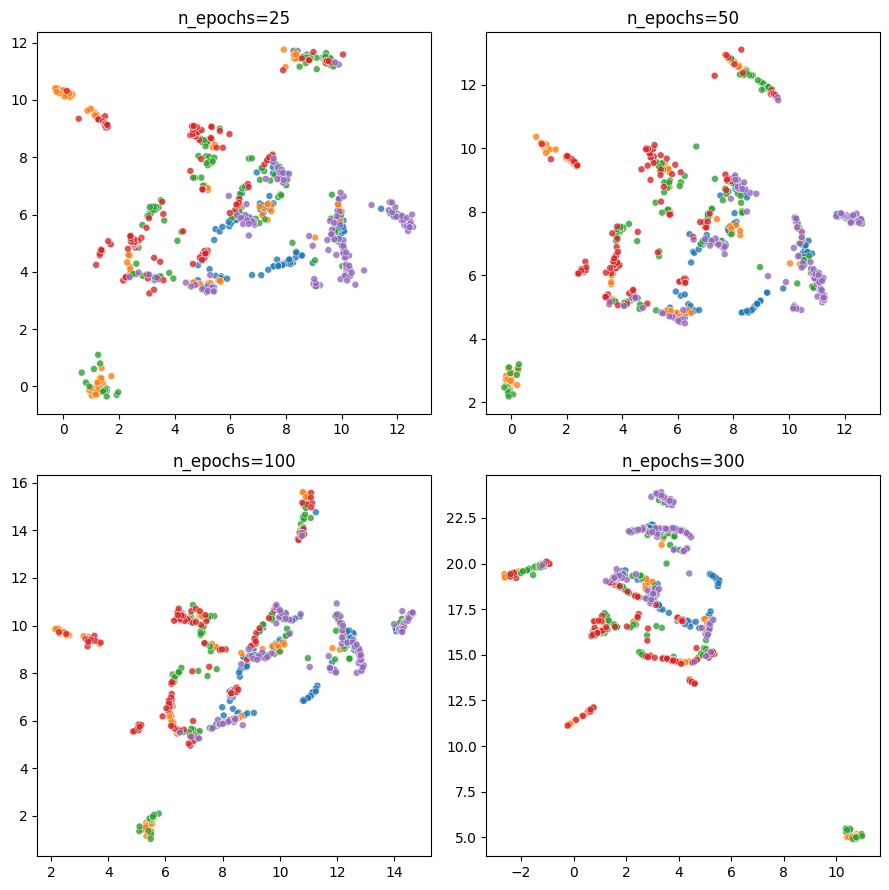

In [20]:

epochs = [25, 50, 100, 300]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
for i, e in enumerate(epochs):
    plot_umap(data=dist_mat, n_epochs=e, ax=axs[i], var="n_epochs")
plt.tight_layout()
plt.show()


learning_rate=1.0 | CA Cont 0.9870 | CA Trust 0.9884 | KNN 0.610 | Geriausias k KNN 8 |
learning_rate=5.0 | CA Cont 0.9900 | CA Trust 0.9864 | KNN 0.600 | Geriausias k KNN 7 |
learning_rate=10 | CA Cont 0.9900 | CA Trust 0.9857 | KNN 0.608 | Geriausias k KNN 5 |
learning_rate=15 | CA Cont 0.9886 | CA Trust 0.9837 | KNN 0.602 | Geriausias k KNN 5 |


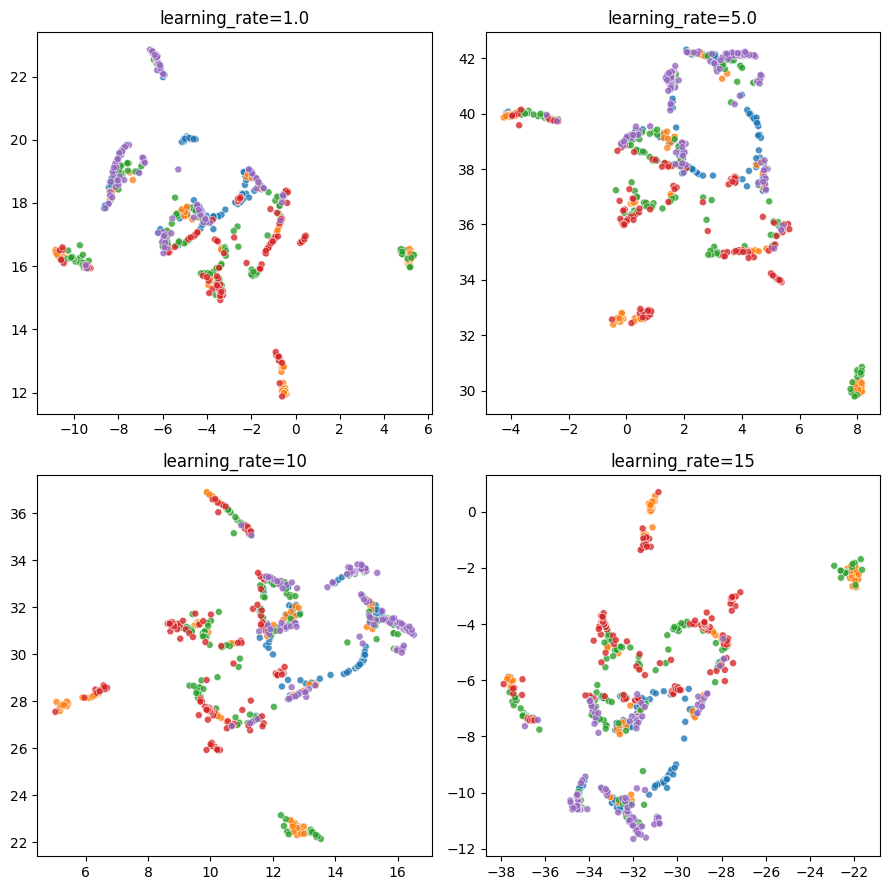

In [21]:

rates = [1.0, 5.0, 10, 15]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
for i, r in enumerate(rates):
    plot_umap(data=dist_mat, learning_rate=r, ax=axs[i], var="learning_rate")
plt.tight_layout()
plt.show()



# kiekvieno metodo geriausiu parametru radimas

In [22]:

def print_individual_bests(all_results_array):
    df = pd.DataFrame(all_results_array)
    # Calculate combined score using exactly your logic
    
    methods = ["MDS", "t-SNE", "UMAP"]
    
    for method in methods:
        method_df = df[df["Method"] == method]
        if method_df.empty:
            continue

        for metric in ['knn_accuracy', 'ca_trustworthiness', 'ca_continuity']:

            best = method_df.sort_values(metric, ascending=False).iloc[0]
                
            print(f"\n--- BEST {method.upper()} CONFIGURATION ACCORDING TO {metric} ---")
            print(f"KNN Accuracy:        {best['knn_accuracy']:.4f}")
            print(f"CA Trustworthiness:  {best['ca_trustworthiness']:.4f}")
            print(f"CA Continuity:       {best['ca_continuity']:.4f}")
                
            # Print only hyperparameters
            standard_cols = ['Method', 'overall_score', 'knn_accuracy', 'ca_trustworthiness', 'ca_continuity', 'best_k', 'embedding']
            hyperparams = {k: v for k, v in best.items() if k not in standard_cols and pd.notna(v)}
            print(f"Parameters:          {hyperparams}")

print_individual_bests(global_all_results)


--- BEST MDS CONFIGURATION ACCORDING TO knn_accuracy ---
KNN Accuracy:        0.5987
CA Trustworthiness:  0.9508
CA Continuity:       0.9836
Parameters:          {'n_init': np.float64(4.0)}

--- BEST MDS CONFIGURATION ACCORDING TO ca_trustworthiness ---
KNN Accuracy:        0.5902
CA Trustworthiness:  0.9530
CA Continuity:       0.9827
Parameters:          {'n_init': np.float64(1.0)}

--- BEST MDS CONFIGURATION ACCORDING TO ca_continuity ---
KNN Accuracy:        0.5880
CA Trustworthiness:  0.9474
CA Continuity:       0.9868
Parameters:          {'n_init': np.float64(32.0)}

--- BEST T-SNE CONFIGURATION ACCORDING TO knn_accuracy ---
KNN Accuracy:        0.7020
CA Trustworthiness:  0.9758
CA Continuity:       0.9861
Parameters:          {'max_iter': np.float64(500.0), 'perplexity': np.float64(5.0), 'early_exaggeration': np.float64(24.0), 'learning_rate': np.float64(10.0)}

--- BEST T-SNE CONFIGURATION ACCORDING TO ca_trustworthiness ---
KNN Accuracy:        0.6234
CA Trustworthiness:  0

In [23]:
umap_results = list( filter(lambda x: (x['Method'] == 'UMAP'), global_all_results) )
sorted(umap_results, key=lambda x: -1 * x['knn_accuracy'])

[]

# geriausio metodo radimas

In [24]:

def find_best_overall_method(all_results_array):
    df = pd.DataFrame(all_results_array)

    best_methods = []
    for metric in ['knn_accuracy', 'ca_trustworthiness', 'ca_continuity']:

        best = df.sort_values(metric, ascending=False).iloc[0]
                
        print(f"\n--- BEST METHOD ACCORDING TO {metric} ---")
        print(f"Algorithm:           {best['Method']}")
        print(f"KNN Accuracy:        {best['knn_accuracy']:.4f}")
        print(f"CA Trustworthiness:  {best['ca_trustworthiness']:.4f}")
        print(f"CA Continuity:       {best['ca_continuity']:.4f}")
                
        # Print only hyperparameters
        standard_cols = ['Method', 'knn_accuracy', 'ca_trustworthiness', 'ca_continuity', 'best_k', 'embedding']
        hyperparams = {k: v for k, v in best.items() if k not in standard_cols and pd.notna(v)}
        print(f"Parameters:          {hyperparams}") 

        best_methods.append(best)
    
    return best_methods

best_methods = find_best_overall_method(global_all_results)


--- BEST METHOD ACCORDING TO knn_accuracy ---
Algorithm:           t-SNE
KNN Accuracy:        0.7020
CA Trustworthiness:  0.9758
CA Continuity:       0.9861
Parameters:          {'max_iter': np.float64(500.0), 'perplexity': np.float64(5.0), 'early_exaggeration': np.float64(24.0), 'learning_rate': np.float64(10.0)}

--- BEST METHOD ACCORDING TO ca_trustworthiness ---
Algorithm:           t-SNE
KNN Accuracy:        0.6234
CA Trustworthiness:  0.9923
CA Continuity:       0.9930
Parameters:          {'max_iter': np.float64(2000.0), 'perplexity': np.float64(50.0), 'early_exaggeration': np.float64(4.0), 'learning_rate': np.float64(10.0)}

--- BEST METHOD ACCORDING TO ca_continuity ---
Algorithm:           t-SNE
KNN Accuracy:        0.6085
CA Trustworthiness:  0.9872
CA Continuity:       0.9943
Parameters:          {'max_iter': np.float64(2000.0), 'perplexity': np.float64(200.0), 'early_exaggeration': np.float64(4.0), 'learning_rate': np.float64(100.0)}



Plotting t-SNE with cleaned parameters: {'max_iter': 500, 'perplexity': np.float64(5.0), 'early_exaggeration': np.float64(24.0), 'learning_rate': np.float64(10.0)}


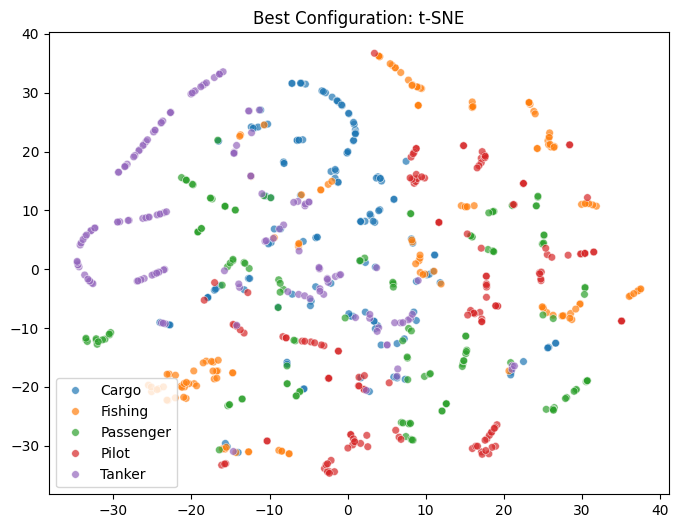


Plotting t-SNE with cleaned parameters: {'max_iter': 2000, 'perplexity': np.float64(50.0), 'early_exaggeration': np.float64(4.0), 'learning_rate': np.float64(10.0)}


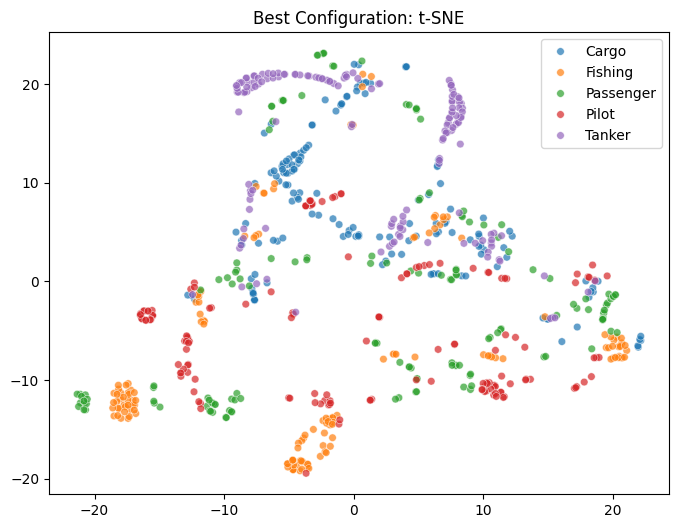


Plotting t-SNE with cleaned parameters: {'max_iter': 2000, 'perplexity': np.float64(200.0), 'early_exaggeration': np.float64(4.0), 'learning_rate': np.float64(100.0)}


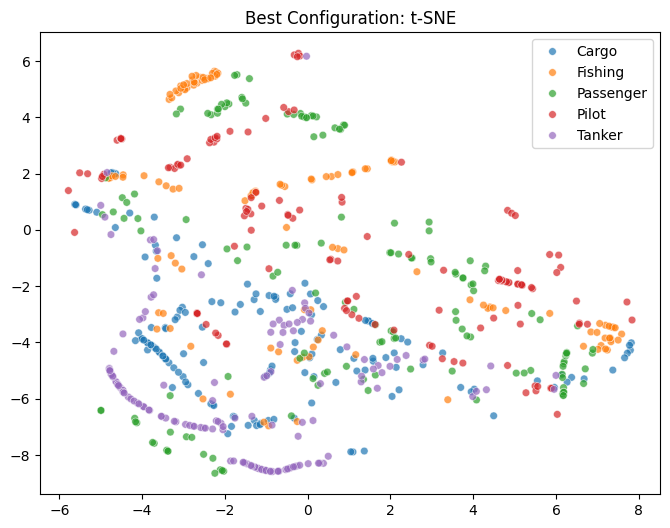

In [25]:
def plot_best_result(best_config):
    method = best_config['Method']
    
    # 1. Extract and CLEAN parameters
    standard_cols = ['Method', 'overall_score', 'knn_accuracy', 'ca_trustworthiness', 'ca_continuity', 'best_k', 'embedding']
    params = {k: v for k, v in best_config.items() if k not in standard_cols and pd.notna(v)}
    
    # Clean n_epochs: if it's None or NaN, remove it so UMAP uses its default
    if 'n_epochs' in params and (params['n_epochs'] is None or pd.isna(params['n_epochs'])):
        del params['n_epochs']
    
    # Ensure types are correct for UMAP/t-SNE/MDS
    if 'n_neighbors' in params: params['n_neighbors'] = int(params['n_neighbors'])
    if 'n_epochs' in params: params['n_epochs'] = int(params['n_epochs'])
    if 'max_iter' in params: params['max_iter'] = int(params['max_iter'])
    if 'n_init' in params: params['n_init'] = int(params['n_init'])
    
    print(f"\nPlotting {method} with cleaned parameters: {params}")
    
    plt.figure(figsize=(8, 6))
    
    if method == "UMAP":
        # Pass cleaned params
        model = UMAP(metric="precomputed", **params, random_state=42)
        embedding = model.fit_transform(dist_mat)
        
    elif method == "t-SNE":
        # t-SNE often dislikes 'n_epochs' if it accidentally got into the params
        if 'n_epochs' in params: del params['n_epochs']
        model = TSNE(metric="precomputed", init="random", **params, random_state=42)
        embedding = model.fit_transform(dist_mat)
        
    elif method == "MDS":
        model = MDS(dissimilarity="precomputed", metric=True, **params, random_state=42)
        embedding = model.fit_transform(dist_mat)
        
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette="tab10", s=30, alpha=0.7)
    plt.title(f"Best Configuration: {method}")
    plt.show()

# Execute the plot
for best in best_methods:
    plot_best_result(best)

In [31]:
cross_val_score( knn_clas, embedding, labels, cv=5 ).mean()

np.float64(0.7213333333333333)

In [27]:
knn_clas = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print( cross_val_score(knn_clas, original_flat, labels, cv=5).mean() )

0.7546666666666667
